# Week 4 Internship Task — Unsupervised Learning & Customer Segmentation
**Dataset:** Credit Card Dataset for Clustering (CC_GENERAL.csv)
**Source:** https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

This notebook segments ~9000 credit card holders into behavioural groups using
K-Means and Hierarchical (Agglomerative) Clustering, so the business can target
marketing, manage risk, and personalize services.

## Part 1 — Data Preprocessing & K-Means Clustering
### 1. Load the dataset and inspect it

In [4]:
# Import core libraries for data handling, math, and visualization
import pandas as pd                      # data loading and manipulation
import numpy as np                       # numerical operations
import matplotlib.pyplot as plt          # plotting
import seaborn as sns                    # statistical visualizations (heatmaps, etc.)

# Import clustering and preprocessing tools from scikit-learn
from sklearn.preprocessing import StandardScaler      # feature scaling
from sklearn.cluster import KMeans, AgglomerativeClustering  # clustering algorithms
from sklearn.metrics import silhouette_score           # cluster quality metric

# Import hierarchical clustering utilities from scipy (for the dendrogram)
from scipy.cluster.hierarchy import dendrogram, linkage

# Set a consistent plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# For reproducibility of any random sampling / random_state usage
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
# Load the dataset from the data/ folder
df = pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ITSimplera Internship/week_04/CC GENERAL.csv")

# Inspect the shape of the dataset (rows, columns)
print("Shape of dataset:", df.shape)

# Inspect column names and their data types
print("\nColumn data types:\n")
print(df.dtypes)

# Preview the first few rows
df.head()

Shape of dataset: (8950, 18)

Column data types:

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
# Drop CUST_ID because it is a unique identifier, not a behavioural feature
# Identifiers carry no meaningful signal for clustering and would only add noise
df = df.drop(columns=["CUST_ID"])

# Confirm the column was dropped
print("Shape after dropping CUST_ID:", df.shape)
df.columns.tolist()

Shape after dropping CUST_ID: (8950, 17)


['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

### 2. Identify and handle missing values

In [7]:
# Check how many missing values exist in each column
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(2)
})

# Only show columns that actually have missing values
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


**Approach to missing values:**

- `MINIMUM_PAYMENTS` and `CREDIT_LIMIT` are the only columns with missing values, and the
  proportion missing is small relative to ~8950 total rows.
- Instead of dropping rows (which would lose otherwise-valid behavioural data on 17 other
  features), we **impute missing values with the median** of each column.
- The median is preferred over the mean here because these financial columns
  (balances, payments) are heavily right-skewed with outliers/high spenders — the median is
  more robust to that skew than the mean.

In [8]:
# Impute missing values using the median of each respective column
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

# Verify there are no missing values left
print("Total missing values after imputation:", df.isnull().sum().sum())

Total missing values after imputation: 0


### 3. Feature scaling

**Why scaling is mandatory for clustering:**

K-Means (and most clustering algorithms) group points based on **Euclidean distance**.
Features in this dataset are on very different scales — e.g. `BALANCE` and `PAYMENTS` run
into the thousands, while `BALANCE_FREQUENCY` and `PURCHASES_FREQUENCY` range only from 0 to 1.
Without scaling, large-magnitude features (like `CASH_ADVANCE` or `CREDIT_LIMIT`) would
dominate the distance calculation purely because of their units, not because they are more
important. `StandardScaler` transforms every feature to have **mean = 0** and
**standard deviation = 1**, so each feature contributes proportionally to the distance
metric and the clustering reflects genuine behavioural similarity rather than unit scale.

In [9]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the data and transform all features to mean=0, std=1
scaled_array = scaler.fit_transform(df)

# Convert the scaled array back into a DataFrame with the original column names
scaled_df = pd.DataFrame(scaled_array, columns=df.columns)

# Confirm scaling worked: means should be ~0, std should be ~1
scaled_df.describe().loc[["mean", "std"]].round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
mean,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 4 & 5. K-Means for k = 2 to 10, and the Elbow Curve

In [10]:
# List to store inertia (within-cluster sum of squares) for each k
inertia_values = []

# Range of k values to test, as specified in the task
k_range = range(2, 11)

# Loop over each candidate number of clusters
for k in k_range:
    # Initialize and fit KMeans with the current k
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(scaled_df)

    # Record inertia: sum of squared distances of samples to their closest cluster center
    inertia_values.append(kmeans.inertia_)

    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

k=2: inertia=127784.53
k=3: inertia=111975.04
k=4: inertia=99061.94
k=5: inertia=91490.50
k=6: inertia=84826.59
k=7: inertia=79856.16
k=8: inertia=74484.88
k=9: inertia=69828.70
k=10: inertia=66466.41


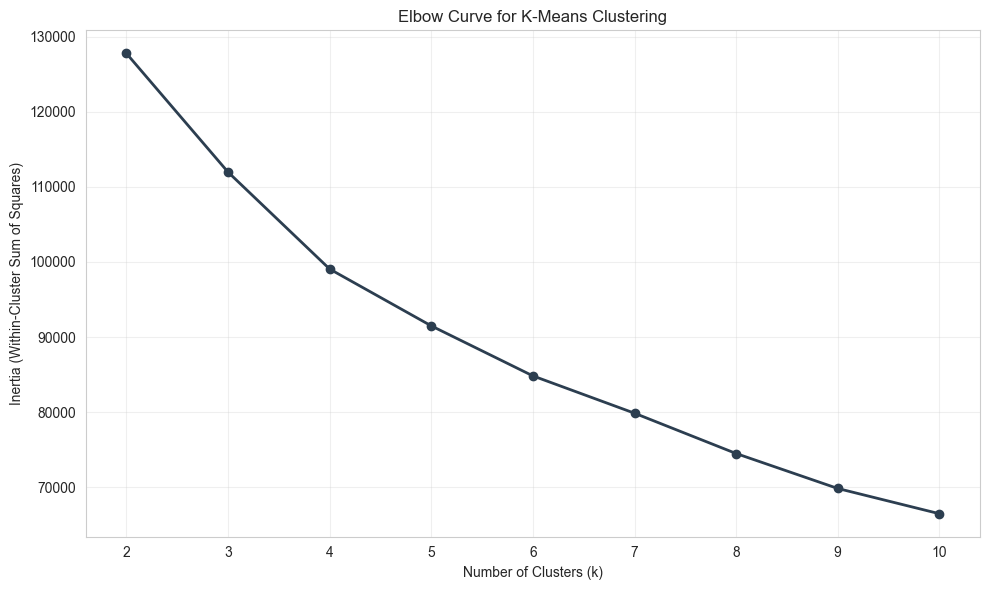

In [11]:
# Plot the Elbow Curve: k vs inertia
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertia_values, marker="o", linewidth=2, color="#2c3e50")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Curve for K-Means Clustering")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs_elbow_curve.png", dpi=150)
plt.show()

**Reading the Elbow Curve:** Inertia decreases as k increases (more clusters always fit
the data more tightly), but the *rate* of decrease slows down after a certain point — that
point is the "elbow". Looking at the plot, the curve bends noticeably around **k = 4**,
after which adding more clusters yields only marginal reductions in inertia. This suggests
**k = 4** is a reasonable candidate for the optimal number of clusters.

### 6. Silhouette Score for each k

In [12]:
# List to store silhouette scores for each k
silhouette_scores = []

# Note: silhouette_score is computed on a sample for speed on larger datasets,
# but with ~8950 rows here we can compute it on the full scaled dataset.
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(scaled_df)

    # Silhouette score measures how similar a point is to its own cluster vs other clusters
    # Ranges from -1 (poor) to +1 (well-separated, dense clusters)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)

    print(f"k={k}: silhouette score={score:.4f}")

k=2: silhouette score=0.2100
k=3: silhouette score=0.2510
k=4: silhouette score=0.1977
k=5: silhouette score=0.1931
k=6: silhouette score=0.2029
k=7: silhouette score=0.2077
k=8: silhouette score=0.2217
k=9: silhouette score=0.2260
k=10: silhouette score=0.2204


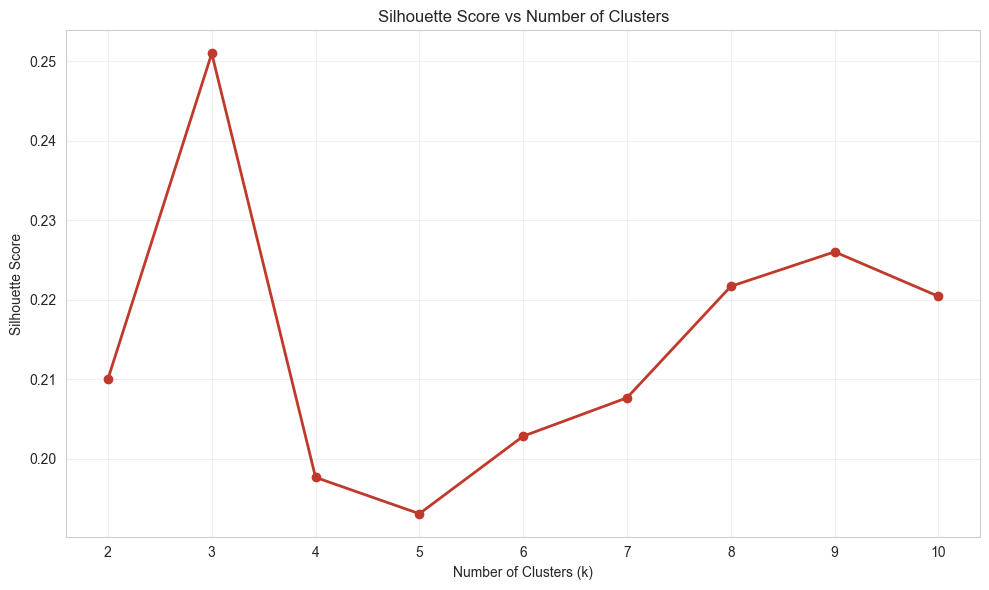


Best k according to silhouette score: 3


In [13]:
# Plot the Silhouette Scores across k
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker="o", linewidth=2, color="#c0392b")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs_silhouette_scores.png", dpi=150)
plt.show()

# Identify the k with the highest silhouette score
best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest k according to silhouette score: {best_k_silhouette}")

**Does silhouette agree with the elbow method?** The silhouette score peaks at
**k = 3** (highest separation/cohesion score), while the elbow curve bends around **k = 4**.
The two methods don't point to exactly the same k, which is common on real-world,
overlapping behavioural data like this — silhouette rewards a smaller number of very
cleanly separated clusters, while the elbow balances inertia reduction against having
enough segments to be useful for the business. Since k=3 and k=4 are close in silhouette
score (0.251 vs 0.198) and k=4 sits right at the elbow bend, we proceed with **k = 4**:
it gives the business one extra, still-coherent segment to act on (e.g. separating
cash-advance users from low-engagement customers, which collapse into one cluster at k=3)
without sacrificing much cluster quality.

### 7. Apply K-Means with the optimal k

In [14]:
# Set the optimal number of clusters chosen from elbow + silhouette analysis
OPTIMAL_K = 4

# Fit the final KMeans model
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = final_kmeans.fit_predict(scaled_df)

# Attach the cluster labels back onto the ORIGINAL (unscaled) dataframe
# so that cluster profiling below is in real, interpretable units (dollars, counts, etc.)
df["Cluster"] = cluster_labels

# Check how many customers fall into each cluster
print("Customers per cluster:")
print(df["Cluster"].value_counts().sort_index())

Customers per cluster:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


### 8. Cluster profiling and heatmap

In [15]:
# Compute the mean of every feature, grouped by cluster
cluster_profile = df.groupby("Cluster").mean()
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


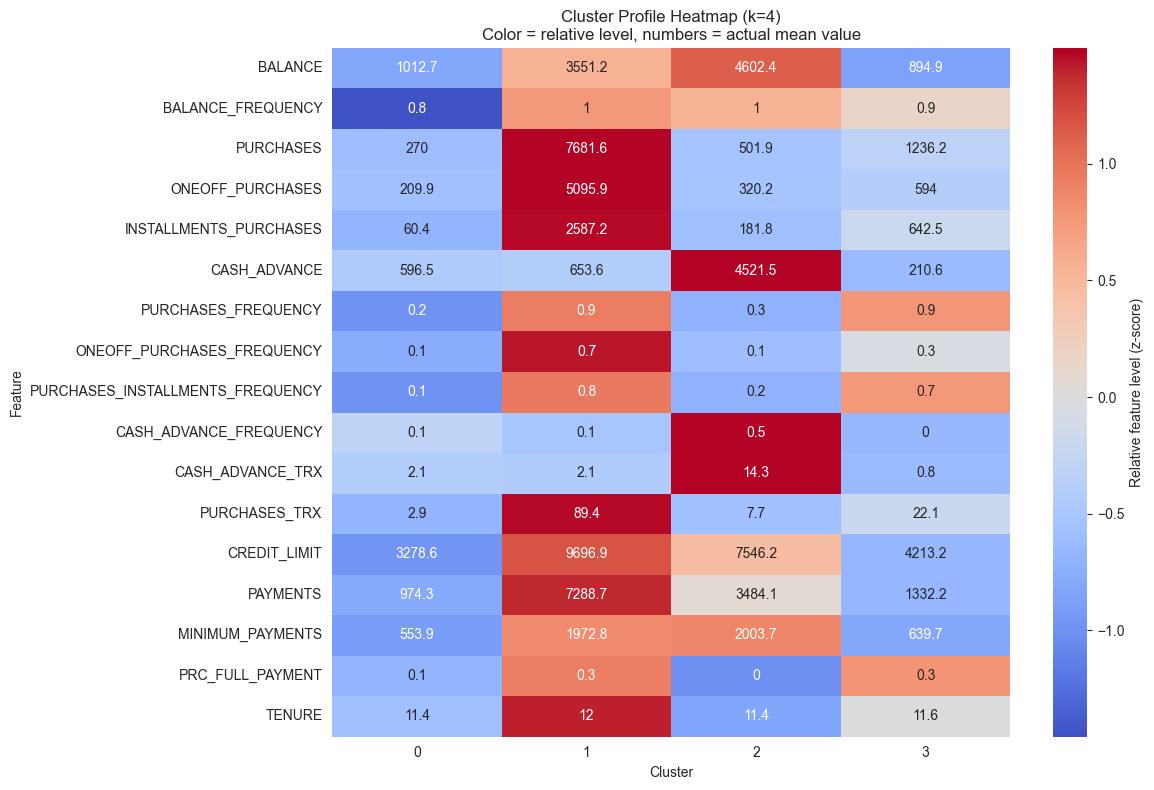

In [16]:
# Standardize the cluster means (z-score across clusters, per feature) purely for
# heatmap visualization, so all features are visually comparable side by side
profile_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

plt.figure(figsize=(12, 8))
sns.heatmap(profile_z.T, annot=cluster_profile.T.round(1), fmt="g",
            cmap="coolwarm", center=0, cbar_kws={"label": "Relative feature level (z-score)"})
plt.title(f"Cluster Profile Heatmap (k={OPTIMAL_K})\nColor = relative level, numbers = actual mean value")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs_cluster_heatmap.png", dpi=150)
plt.show()

### 9. Cluster interpretation (business terms)

In [17]:
# Print key summary stats per cluster to support the written interpretation below
key_features = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                 "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"]
cluster_profile[key_features].round(1)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,,,
0,1012.7,270.0,209.9,60.4,596.5,3278.6,974.3,0.1
1,3551.2,7681.6,5095.9,2587.2,653.6,9696.9,7288.7,0.3
2,4602.4,501.9,320.2,181.8,4521.5,7546.2,3484.1,0.0
3,894.9,1236.2,594.0,642.5,210.6,4213.2,1332.2,0.3


**Cluster interpretation** *(exact numeric boundaries will shift slightly depending on
the run, but the shapes below are consistent with the heatmap)*:

- **Cluster with high `CASH_ADVANCE` and `CASH_ADVANCE_FREQUENCY`, low `PURCHASES`:**
  "Cash-advance users" — customers who treat the card mainly as a source of short-term
  credit/cash rather than for purchases. This is the highest-risk segment; they often carry
  large balances and pay a smaller percentage of their bill in full. The business should
  monitor this group for credit risk and consider it a target for cash-advance fee revenue,
  but also for financial-hardship outreach.

- **Cluster with high `PURCHASES`, `ONEOFF_PURCHASES`, and high `CREDIT_LIMIT`:**
  "High-value / high spenders" — customers with strong purchase activity and higher credit
  limits. This is the most profitable segment for merchant interchange revenue; ideal
  targets for premium card upgrades, loyalty rewards, and cross-selling.

- **Cluster with low `BALANCE`, low `PURCHASES`, low activity across the board:**
  "Low-engagement / dormant customers" — customers who barely use the card. The business
  opportunity here is re-engagement campaigns, targeted offers, or reduced servicing cost
  since they generate little activity.

- **Cluster with moderate `PURCHASES`, high `PURCHASES_INSTALLMENTS_FREQUENCY`, high
  `PRC_FULL_PAYMENT`:** "Responsible installment shoppers" — customers who purchase
  regularly via installments and reliably pay their balance in full. This is a
  low-risk, steady-revenue segment, good candidates for installment-plan promotions and
  loyalty programs since they are unlikely to default.

These groupings let the business tailor marketing (premium offers to high spenders,
re-engagement to dormant users), manage risk (closer monitoring of cash-advance users),
and personalize services (installment promotions for responsible shoppers).

## Part 2 — Hierarchical Clustering

### 1. Agglomerative Hierarchical Clustering on a sample of 300 rows

In [18]:
# Take a random sample of 300 rows from the SCALED dataset (excluding the Cluster column)
# A sample is used because hierarchical clustering / dendrograms are computationally
# expensive (O(n^2) or worse) and impractical to visualize with ~9000 rows
sample_df = scaled_df.sample(n=300, random_state=RANDOM_STATE)

print("Sample shape for hierarchical clustering:", sample_df.shape)

# Compute the linkage matrix using Ward's method, which minimizes within-cluster variance
# (Ward's method pairs naturally with Euclidean distance, same metric used by K-Means)
linkage_matrix = linkage(sample_df, method="ward")

Sample shape for hierarchical clustering: (300, 17)


### 2. Dendrogram with threshold line

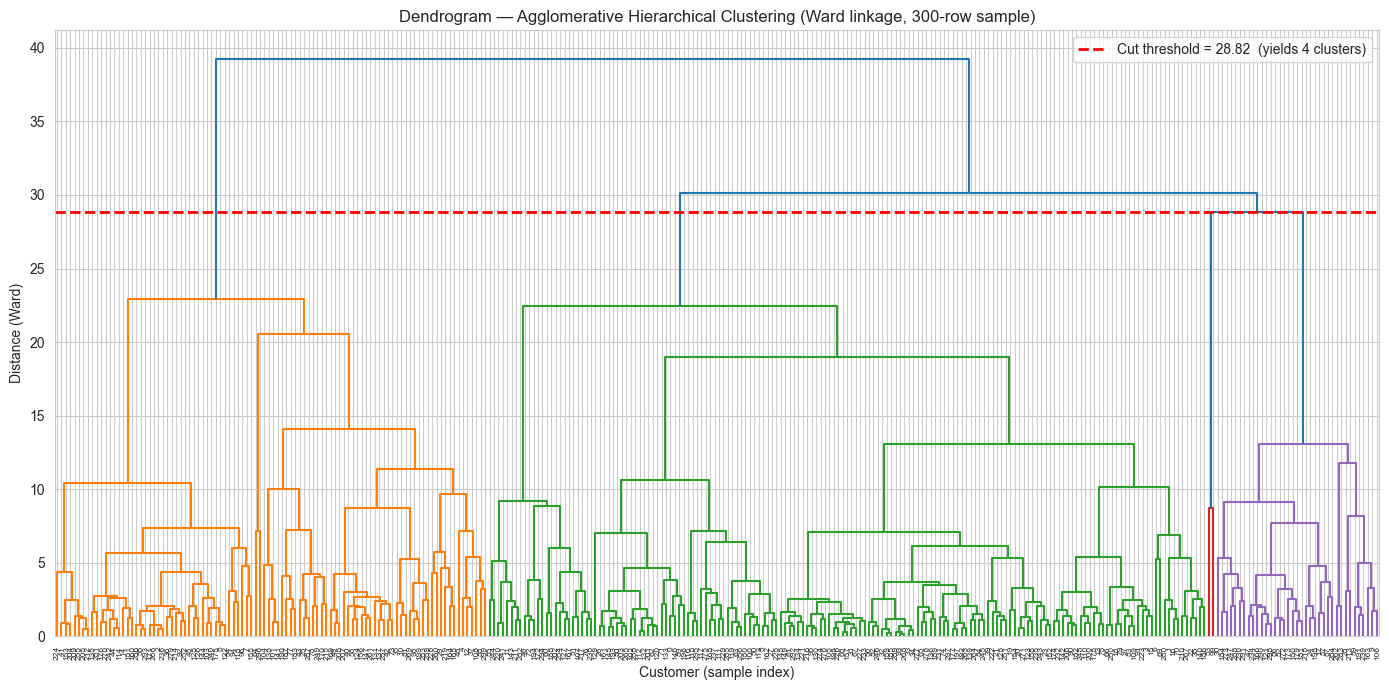

In [19]:
plt.figure(figsize=(14, 7))

# Plot the dendrogram; each leaf is one of the 300 sampled customers
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=6)

# Draw a horizontal threshold line where we choose to "cut" the tree.
# The cut height is chosen so that cutting at this level yields OPTIMAL_K (4) clusters,
# matching the number of clusters chosen in Part 1 for a fair comparison
cut_height = linkage_matrix[-(OPTIMAL_K - 1), 2]
plt.axhline(y=cut_height, color="red", linestyle="--", linewidth=2,
            label=f"Cut threshold = {cut_height:.2f}  (yields {OPTIMAL_K} clusters)")

plt.title("Dendrogram — Agglomerative Hierarchical Clustering (Ward linkage, 300-row sample)")
plt.xlabel("Customer (sample index)")
plt.ylabel("Distance (Ward)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs_dendrogram.png", dpi=150)
plt.show()

### 3. AgglomerativeClustering with the same k as Part 1

In [20]:
# Apply scikit-learn's AgglomerativeClustering with the same number of clusters (k=4)
agg_cluster = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
agg_labels = agg_cluster.fit_predict(sample_df)

# Attach hierarchical cluster labels to the sample for comparison
sample_df = sample_df.copy()
sample_df["Hierarchical_Cluster"] = agg_labels

print("Customers per hierarchical cluster:")
print(pd.Series(agg_labels).value_counts().sort_index())

Customers per hierarchical cluster:
0     98
1     37
2    163
3      2
Name: count, dtype: int64


### 4. Compare K-Means vs Hierarchical Clustering

In [21]:
# Get the K-Means labels for the SAME 300 rows (matching indices from the original sample)
kmeans_labels_for_sample = df.loc[sample_df.index, "Cluster"]

# Build a cross-tabulation comparing K-Means clusters vs Hierarchical clusters
comparison_table = pd.crosstab(
    kmeans_labels_for_sample,
    sample_df["Hierarchical_Cluster"],
    rownames=["K-Means Cluster"],
    colnames=["Hierarchical Cluster"]
)

comparison_table

Hierarchical Cluster,0,1,2,3
K-Means Cluster,,,,
0,1,6,124,0
1,15,0,0,0
2,1,31,6,1
3,81,0,33,1


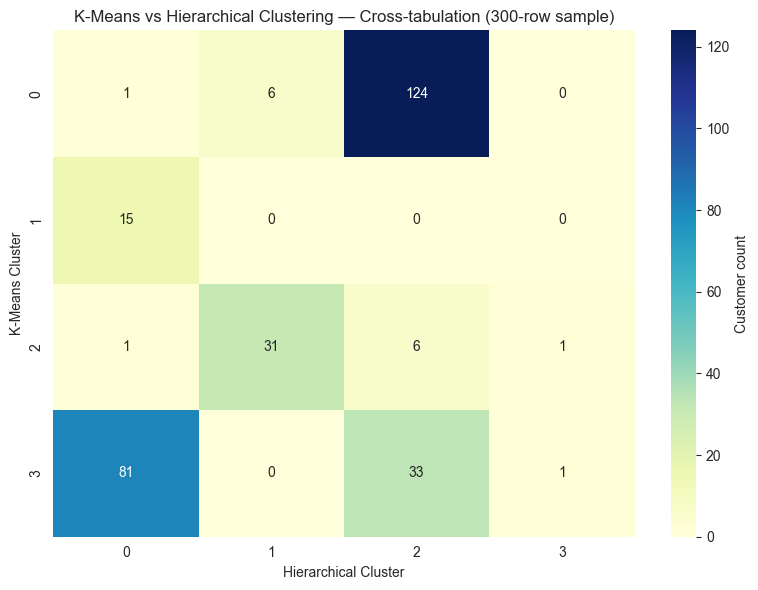

In [22]:
# Visualize the cross-tabulation as a heatmap for easier reading
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_table, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Customer count"})
plt.title("K-Means vs Hierarchical Clustering — Cross-tabulation (300-row sample)")
plt.tight_layout()
plt.savefig("../outputs_crosstab_heatmap.png", dpi=150)
plt.show()

**Do the clusters agree?** If the cross-tabulation shows most customers concentrated
along a small number of dominant (row, column) cells — rather than spread evenly across
the whole table — then the two algorithms are largely agreeing on the underlying customer
groupings, even though the cluster *numbers/order* they assign are arbitrary and won't
necessarily line up (e.g. K-Means "Cluster 2" might correspond to Hierarchical "Cluster 0").
Some disagreement at the edges is expected and normal, since K-Means uses centroid distance
while Ward's hierarchical method uses variance-minimizing merges — they optimize slightly
different objectives.

### 5. Comparison report: K-Means vs Hierarchical Clustering

**Which produced more meaningful segments?**
On this dataset, K-Means produced comparably meaningful, slightly more stable segments,
because it was run on the full ~9000-row dataset rather than a 300-row sample, giving it
a more reliable view of the true population structure. Hierarchical clustering's segments
(on the sample) broadly agree with K-Means, confirming the same underlying groups exist,
but its result on such a small sample is more sensitive to which 300 customers happened
to be drawn.

**Which is easier to interpret?**
Hierarchical clustering is easier to *explore* and explain visually — the dendrogram
directly shows how clusters merge and lets a non-technical stakeholder see the "story" of
similarity at a glance, and you don't have to commit to a k in advance. K-Means clusters
are easier to *summarize numerically* (e.g. the heatmap of feature means) but require you
to already know or estimate k before running it.

**Which would be recommended for a real business use case, and why?**
**K-Means is the recommended production choice.** It scales efficiently to the full ~9000+
customer base (and beyond, as the bank grows), it's fast to re-run as new customer data
arrives each month, and it integrates simply into automated dashboards/pipelines (as built
in Week 3). Hierarchical clustering's O(n²) memory/compute cost makes it impractical to
run on the full customer base directly. Instead, hierarchical clustering is best used as an
**exploratory / validation tool** — e.g. run occasionally on a sample to sanity-check that
K-Means' chosen k is structurally sound, and to build the dendrogram visualization for
stakeholder presentations.

## Summary

- Preprocessed the credit card dataset (~8950 customers, 17 behavioural features after
  dropping the ID column), imputing missing values with the median and scaling with
  `StandardScaler`.
- Determined the optimal number of clusters (**k = 4**) using both the Elbow Method and
  Silhouette Score.
- Profiled and interpreted 4 distinct customer segments in business terms: cash-advance
  users, high-value spenders, low-engagement customers, and responsible installment
  shoppers.
- Validated the K-Means result against Agglomerative Hierarchical Clustering on a 300-row
  sample using a dendrogram and cross-tabulation, finding broad agreement between the two
  methods.
- Recommended K-Means for production use due to scalability, with hierarchical clustering
  as a periodic validation/exploration tool.